 # Homework 🔬 (20 pts, teams of max. 3)
  Analyse the influence of additive noise on blind source separation. Given a
  mixture signal for which the true sources are known, your goal is to evaluate
  how well a separation model performs when the input mixture is corrupted by
  Gaussian noise $z \sim \mathcal{N}(0, \sigma^2)$, for varying noise
  levels $\sigma$.

 **0. Loading Baseline Model and Prepping Dataset**

In [9]:
import os
# print(__file__)
# file_dir, _ = os.path.split(__file__)
# if not (os.path.abspath(os.getcwd()) is os.path.abspath(file_dir)):
#     os.chdir(file_dir)

from convtasnet import ConvTasNet, SI_SNR_PIT
from hw_utils import prep_dataset, LibriMixDataset

import lighter

import torch
from torch.utils.data import DataLoader

import toml

import pandas as pd

import numpy as np
import librosa
import soundfile as sf
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

config_path = './noisy_ss.toml'
model_path = './models/ConvTasNet_Noise.pth'
results_path = './main_results.csv'

with open(config_path, 'r') as f:
    config = toml.load(f)

config_dir, _ = os.path.split(config_path)
working_dir = config.get('working_dir', config_dir)

os.chdir(working_dir)

dataset_path = config['dataset'].get('root')
prep_dataset(dataset_path)

model = ConvTasNet(**config['model'])

model.compile(
    torch.optim.Adam(model.parameters(), **config['optimizer']),
    SI_SNR_PIT(),
    metrics=[],
    device=device,
)

model.load('models/ConvTasNet_Baseline.pth')

if os.path.exists('main_results.toml'):
    results = toml.load('main_results.toml')
else:
    results = {
        'model'     : [],
        'l_sigma0'  : [],
        'l_sigma1'  : [],
        'l_sigma2'  : [],
        'sig0'      : 0,
        'sig1'      : 0,
        'sig2'      : 0,
    }


  **1. Choose noise levels (`4 pts`)**
  Select three distinct values of $\sigma$ such that the SNR between the clean
  mixture $x$ and the noisy mixture $x + z$ satisfies:
  $$\text{SNR}(x,\, x+z) \leq 20\ \text{dB}$$
  For each chosen $\sigma$, report the corresponding SNR (in dB). Make sure the
  three values span a meaningful range (e.g., low, medium, and high noise).
  > 💡 Recall: $\text{SNR} = 10 \log_{10}\left(\frac{\|x\|^2}{\|z\|^2}\right)$

In [10]:
path_train = os.path.join(dataset_path, 'MiniLibriMix/train')
path_val   = os.path.join(dataset_path, 'MiniLibriMix/val')

sigmas = [0.005, 0.01, 0.02]

snr_sum = 0

def add_noise(input_path, sigma=0.01, output_folder_name='sigmatest', sample_rate=8000):
    """
    :param input_path: path to .wav file
    :param sigma: standard deviation of noise distribution
    :param output_folder_name: folder name for processed .wav, ex: sigma0
    :param sample_rate: signal sample rate
    """

    set_path = os.path.dirname(os.path.dirname(input_path))

    assert os.path.basename(set_path) in ['train', 'val']

    original, sr = librosa.load(input_path, sr=sample_rate)
    noise = np.random.normal(0, sigma, original.shape).astype(np.float32)

    combined = original + noise

    global snr_sum
    snr_sum += 10*np.log10(np.mean(original**2) / np.mean(noise**2))

    if not os.path.exists(os.path.join(set_path, output_folder_name)):
        os.makedirs(os.path.join(set_path, output_folder_name))

    if not os.path.exists(os.path.join(set_path, f'mix_{output_folder_name}')):
        os.makedirs(os.path.join(set_path, f'mix_{output_folder_name}'))

    input_file_name = os.path.basename(input_path)

    sf.write(os.path.join(set_path, output_folder_name, input_file_name), noise, sr)
    sf.write(os.path.join(set_path, f'mix_{output_folder_name}', input_file_name), combined, sr)


def add_metadata(folder_path):
    """
    :param folder_path: path to .wav noise files, ex: sigma0, not mix_sigma0
    """
    def change_path(original_path, folder_name):
        base_path = os.path.dirname(os.path.dirname(original_path))
        base_name = os.path.basename(original_path)

        final = os.path.join(base_path, folder_name, base_name)
        final = final.replace("\\", "/")

        return final

    set_type = os.path.basename(os.path.dirname(folder_path))
    assert set_type in ['train', 'val']

    metadata_folder = os.path.join(os.path.dirname(os.path.dirname(folder_path)), 'metadata')

    df = pd.read_csv(os.path.join(metadata_folder, f'mixture_{set_type}_mix_both.csv'))

    df['mixture_path'] = df['mixture_path'].apply(lambda x: change_path(x, folder_name=f'mix_{os.path.basename(folder_path)}'))

    df['noise_path'] = df['noise_path'].apply(lambda x: change_path(x, folder_name=os.path.basename(folder_path)))

    df.to_csv(os.path.join(metadata_folder, f'mixture_{set_type}_mix_{os.path.basename(folder_path)}.csv'), index=False)


if not os.path.exists(os.path.join(path_val, 'mix_sigma2')) or \
      not os.path.exists('main_results.toml'):
    for add_noise_path in [path_train, path_val]:
        for idx, sgm in enumerate(sigmas):
            snr_sum = 0
            for j, file in enumerate(tqdm(os.listdir(os.path.join(add_noise_path, 'mix_clean')))):
                add_noise(input_path=os.path.join(add_noise_path, 'mix_clean', file), sigma=sgm,
                        output_folder_name=f'sigma{idx}')
            results[f'sig{idx}'] = snr_sum / (j+1)
            add_metadata(os.path.join(add_noise_path, f'sigma{idx}'))


  **2. Evaluate the original model under noise (`8 pts`)**
  For each of the three $\sigma$ values from Task 1, corrupt the **test set** mixtures with noise sampled from $\mathcal{N}(0, \sigma^2)$ and compute the **SI-SNR-PIT** of the original (clean-trained) model.
  - Report all results in the table below *(3 pts)*
  - Analyse the trend: how does increasing noise degrade separation performance? Are the results consistent with your expectations based on the SNR values? *(5 pts)*

In [11]:
if not 'baseline' in results.get('model'):
    results['model'].append('baseline')
    for idx in range(3):
        val_dataset = LibriMixDataset(
            subset="val",
            typ=f'sigma{idx}',
            **config['dataset'],
        )

        val_loader = DataLoader(val_dataset, **config['dataloader'])

        val_l = model.evaluate(
            val_loader,
            callbacks = [
                lighter.callbacks.History(),
            ],
        )

        results[f'l_sigma{idx}'].append(val_l[0])


('data/mini_libri2mix/MiniLibriMix/val/mix_sigma1/1988-148538-0000_3536-8226-0018.wav', ['data/mini_libri2mix/MiniLibriMix/val/s1/1988-148538-0000_3536-8226-0018.wav', 'data/mini_libri2mix/MiniLibriMix/val/s2/1988-148538-0000_3536-8226-0018.wav'], (24000, 48000))


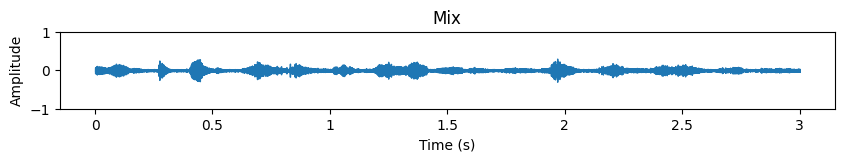

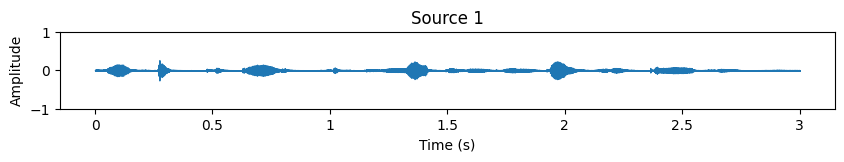

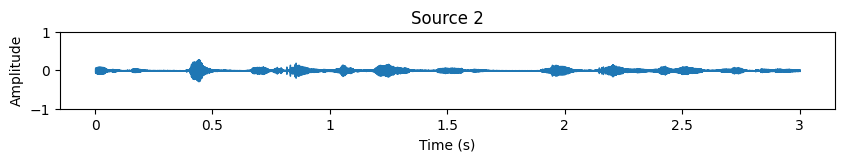

/home/vlad/Facultate/BIOSINF-S2/IA2-proiect/teme/L2/convtasnet.py:288: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than tensor.new_tensor(sourceTensor).
  frame = signal.new_tensor(frame).long() # .clone().detach()


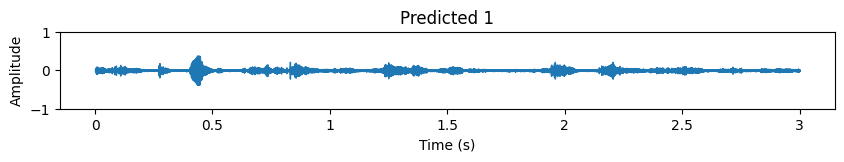

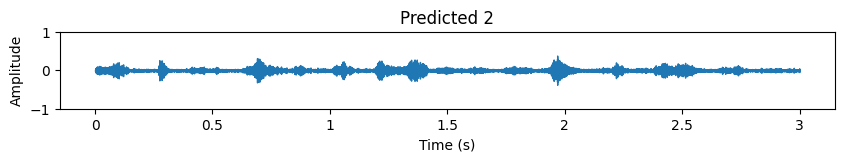

In [12]:
from IPython.display import Audio, display

val_dataset = LibriMixDataset(
    subset="val",
    typ='sigma1',
    **config['dataset'],
)

i = np.random.randint(0, len(val_dataset))

print(val_dataset._get_metadata(i))

mix, sources = val_dataset[i]

val_dataset.listen_samples(i)

sources_pred = model(torch.FloatTensor(mix)[None, ...].to(device)).squeeze()
max_mix = np.max(mix)

sr = config['dataset']['sample_rate']

for i in range(sources_pred.shape[0]):
    signal = sources_pred[i].cpu().detach().numpy()
    signal = signal / np.max(signal) * max_mix
    
    plt.figure(figsize=(10, 1))
    librosa.display.waveshow(signal, sr=sr)
    plt.title(f"Predicted {i+1}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.ylim([-1, 1])
    plt.show()
    
    display(Audio(data=signal, autoplay=False, rate=sr))


  **3. Train a noise-robust model (`8 pts`)**
  Pick **one** of the three $\sigma$ values from Task 1. Train a new model on mixtures perturbed with noise sampled from $\mathcal{N}(0, \sigma^2)$ during training.
  - Evaluate this new model on the **test set** under all three noise conditions and add the results to the table *(3 pts)*
  - Compare and analyse: does training with noise improve robustness? Under which conditions does it help most or least? *(5 pts)*

  **3.1. Training**

In [13]:
if os.path.exists(model_path):
    model.load(model_path)
else:
    train_dataset = LibriMixDataset(
        subset="train",
        typ='sigma1',
        **config['dataset'],
    )

    val_dataset = LibriMixDataset(
        subset="val",
        typ='sigma1',
        **config['dataset'],
    )

    train_loader = DataLoader(train_dataset, **config['dataloader'])
    val_loader   = DataLoader(  val_dataset, **config['dataloader'])

    chkpoint_path = 'models/checkpoints/ConvTasNet_Noise.pt'
    log_path      = 'logs/ConvTasNet_Noise_logs.csv'

    train_l, val_l = model.fit(
        train_loader,
        validation_loader=val_loader,
        callbacks=[
            lighter.callbacks.CSVLogger(log_path),
            lighter.callbacks.History(),
            lighter.callbacks.Checkpoint(
                chkpoint_path,
                save_best_only=True
            ),
        ],
        **config['fit'],
    )

    model.save(model_path)


  **3.2. Evaluation**

In [14]:
if not 'trained' in results.get('model'):
    results['model'].append('trained')
    for idx in range(3):
        val_dataset = LibriMixDataset(
            subset="val",
            typ=f'sigma{idx}',
            **config['dataset'],
        )

        val_loader   = DataLoader(  val_dataset, **config['dataloader'])

        val_l = model.evaluate(
            val_loader,
            callbacks = [
                lighter.callbacks.History(),
            ],
        )

        results[f'l_sigma{idx}'].append(val_l[0])


**3.3 Predictions**

('data/mini_libri2mix/MiniLibriMix/val/mix_sigma1/6345-64257-0009_6295-244435-0037.wav', ['data/mini_libri2mix/MiniLibriMix/val/s1/6345-64257-0009_6295-244435-0037.wav', 'data/mini_libri2mix/MiniLibriMix/val/s2/6345-64257-0009_6295-244435-0037.wav'], (0, 24000))


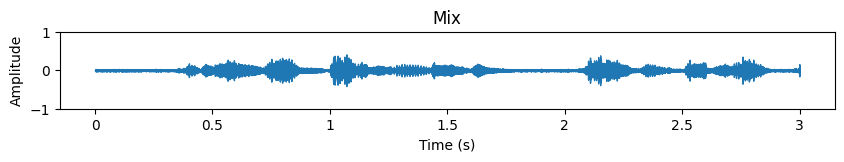

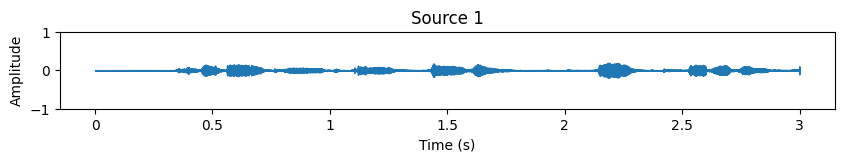

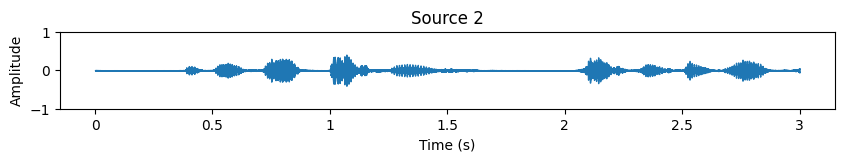

/home/vlad/Facultate/BIOSINF-S2/IA2-proiect/teme/L2/convtasnet.py:288: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than tensor.new_tensor(sourceTensor).
  frame = signal.new_tensor(frame).long() # .clone().detach()


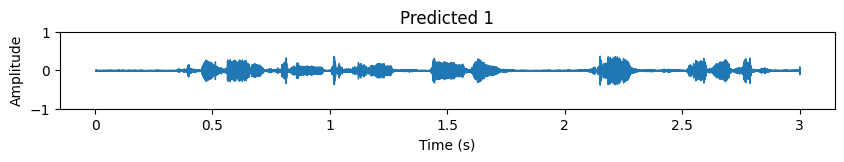

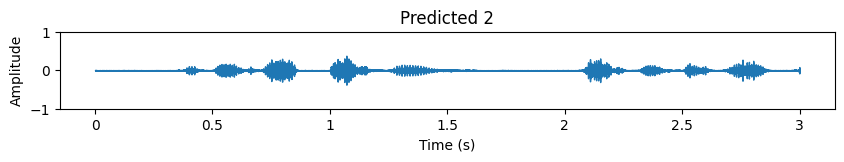

In [15]:
from IPython.display import Audio, display

val_dataset = LibriMixDataset(
    subset="val",
    typ='sigma1',
    **config['dataset'],
)

i = np.random.randint(0, len(val_dataset))

print(val_dataset._get_metadata(i))

mix, sources = val_dataset[i]

val_dataset.listen_samples(i)

sources_pred = model(torch.FloatTensor(mix)[None, ...].to(device)).squeeze()
max_mix = np.max(mix)

sr = config['dataset']['sample_rate']

for i in range(sources_pred.shape[0]):
    signal = sources_pred[i].cpu().detach().numpy()
    signal = signal / np.max(signal) * max_mix
    
    plt.figure(figsize=(10, 1))
    librosa.display.waveshow(signal, sr=sr)
    plt.title(f"Predicted {i+1}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.ylim([-1, 1])
    plt.show()
    
    display(Audio(data=signal, autoplay=False, rate=sr))


  **Final table**

In [16]:
with open('main_results.toml', 'w') as f:
    toml.dump(results, f)

from IPython.display import Markdown, display

table = f'''\
<table style="margin: 0px auto;">
<thead>
  <tr>
    <th rowspan="2">Model</th>
    <th colspan="3">SI-SNR-PIT on test set — mixtures perturbed with:</th>
  </tr>
  <tr>
    <th>σ = {sigmas[0]} (SNR ≈ {results['sig0']} dB)</th>
    <th>σ = {sigmas[1]} (SNR ≈ {results['sig1']} dB)</th>
    <th>σ = {sigmas[2]} (SNR ≈ {results['sig2']} dB)</th>
  </tr>
</thead>
<tbody>
  <tr>
    <td>Original model (trained on clean mixtures)</td>
    <td>{results['l_sigma0'][0]}</td>
    <td>{results['l_sigma1'][0]}</td>
    <td>{results['l_sigma2'][0]}</td>
  </tr>
  <tr>
    <td>Model trained on σ = {sigmas[1]}</td>
    <td>{results['l_sigma0'][1]}</td>
    <td>{results['l_sigma1'][1]}</td>
    <td>{results['l_sigma2'][1]}</td>
  </tr>
</tbody>
</table>
'''

display(Markdown(table))


<table style="margin: 0px auto;">
<thead>
  <tr>
    <th rowspan="2">Model</th>
    <th colspan="3">SI-SNR-PIT on test set — mixtures perturbed with:</th>
  </tr>
  <tr>
    <th>σ = 0.005 (SNR ≈ 19.86987593770027 dB)</th>
    <th>σ = 0.01 (SNR ≈ 13.84886530339718 dB)</th>
    <th>σ = 0.02 (SNR ≈ 7.828529803454876 dB)</th>
  </tr>
</thead>
<tbody>
  <tr>
    <td>Original model (trained on clean mixtures)</td>
    <td>-4.225623059272766</td>
    <td>-3.629100203514099</td>
    <td>-1.8683632969856263</td>
  </tr>
  <tr>
    <td>Model trained on σ = 0.01</td>
    <td>-4.505714470999582</td>
    <td>-4.218503590992519</td>
    <td>-3.1311575174331665</td>
  </tr>
</tbody>
</table>
